# Google Colab

This is our first notebook. To create your own copy that you can edit, click on *File | Save a Copy in Drive*. A new tab will open. Select the new tab to work with your own notebook.



# Compartmental models

This notebook also you to compartmental or box models. These models represent the system of study as a set of connected compartments.

Compartmental models allow us to describe how "stocks" such as mass or energy are exchanged among these compartments. These transfers between departments are described by flows.

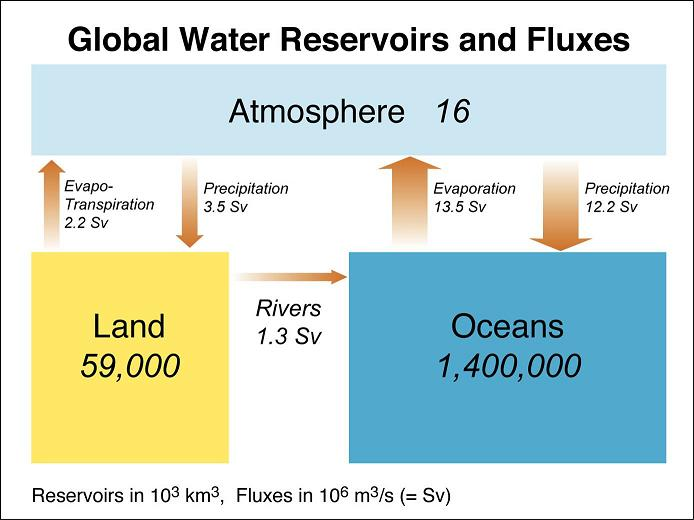

*Three-compartment representation of the global water cycle by Raymond W. Schmitt*.

## Temporal evolution through conservation equations

To track how the "stocks" change over time, we commonly rely on conservation laws. Certain quantities are conserved, i.e., they do not change in an isolated system. These conserved quantities are of fundamental importance to modeling systems. The following quantities are of particular importance to modeling the Earth system: mass, energy, momentum, angular momentum, and electrical charge. We can extend the concept to quantities such as the number of molecules of a given species, accounting for their creation and destruction. Strictly speaking, even mass is not conserved (e.g., radioactive decay), but we can neglect these minor deviations.

### Mass conservation
Let's recall our previous discussion of the conservation of the mass of water. Let $M$ refer to the mass of water in the atmosphere, $Q_{\mathrm{in}}$ the inflow rate (evaporation) and $Q_{\mathrm{out}}$ the outflow rate (precipitation).

Conservation of (water) mass means that the change in mass $\mathrm{d}M$ in an infinitesimal amount of time $\Delta t$ is due to an imbalance between the inflow during th $Q_{\mathrm{in}}\,\Delta t$ and the outflow $Q_{\mathrm{in}}\,\Delta t$. In other words,
$$\Delta M = \left(Q_{\mathrm{in}} - Q_{\mathrm{out}}\right) \Delta t\,.$$
When the inflows exceed the outflows, the mass increases.

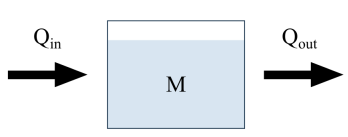

To account for varying fluxes, we can make $\Delta t$ so small that the fluxes can be assumed constant. In the limit, we let $\Delta t \rightarrow 0$ and obtain the following differential equation
$$\frac{\mathrm{d}M}{\mathrm{d}t} = Q_{\mathrm{in}} - Q_{\mathrm{out}}\,.$$

This ordinary differential equation can be solved analytically or numerically to model how the water mass changes over time.

### 😱 Integrating the conservation equation


To model how the mass $M$ changes for known fluxes, we can integrate the mass conservation equation over time. In hydrology, for instance, we may want to know the seasonal change in storage, while the fluxes vary from the day to day.

The change in mass $\Delta M$ from time $t$ to time $t + \Delta t$ is given by

$$\Delta M = \int_{t}^{t+\Delta t} Q_{\mathrm{in}}(t) - Q_{\mathrm{out}}(t)\,\mathrm{d}t,$$

where the integral over, say, the inflow, $M_{\mathrm{in}} \equiv \int Q_{\mathrm{in}}(t)\,\mathrm{d}t$, is the total mass entering the compartment between $t$ and $\Delta t$.

We can reinterpret this equation by defining average flows. The average inflow $\bar{Q}_{\mathrm{in}}$ is obtained by dividing the the total mass entering the compartment by the time period, viz. $\bar{Q}_{\mathrm{in}} \equiv \frac{1}{\Delta t} M_{\mathrm{in}}$. For constant flows $\bar{Q}_{\mathrm{in}} = Q_{\mathrm{in}}$. With this definition,

$$M(t + \Delta t) = M(t) + (\bar{Q}_{\mathrm{in}} - \bar{Q}_{\mathrm{out}}) \Delta t.$$

Thus, the change in mass $\Delta M = M(t+\Delta t) - M(t)$ is given by

$$\Delta M = (\bar{Q}_{\mathrm{in}} - \bar{Q}_{\mathrm{out}}) \Delta t.$$

This more general equation replaces the one we started out with, where we implicitly assumed that the fluxes did not change. Now we know that we can replace them by their average value.

### Exploring the conservation equation

We will now explore the change in water mass of the atmosphere reservoir over a year, assuming constant flows for simplicity.

Click on the little play icon in the upper left corner of the code block below. The code contains a function that produces an animation, which we will display later. Do not worry about the details.

In [ ]:
# Setting up the plotting environment
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation, rc
rc('animation', html='jshtml')

# Function that creates the animation
def create_animation(M, Qin, Qout, frames=12):
  fig, ax = plt.subplots()
  tlim = (0, 1)
  line, = ax.plot([], [], lw=2)
  t = np.linspace(tlim[0], tlim[1], frames)
  ax.set_xlim(tlim)
  ax.set_ylim((0, 2*M))
  ax.set_xlabel('time [months]')
  ax.set_xticks(np.arange(12)/12)
  ax.set_xticklabels(np.arange(12))
  ax.set_ylabel('volume [10$^3$ km$^3$]')

  conv = 1e-6*(60*60*24*365.25)
  M_t = M + (Qin - Qout) * conv * t
  def init():
    line.set_data([], [])
    return (line,)
  def animate(i):
    line.set_data(t[:i], M_t[:i])
    return (line,)
  anim = animation.FuncAnimation(
      fig, animate, init_func=init, frames=frames, interval=100, blit=False)
  return anim

> 🧪 **Work in Pairs: Understanding changes in water mass**
>
> **Instructions:** To see how an imbalance in in- and outflow changes the mass of water in the atmosphere over time, change the values of $Q_{\mathrm{in}}$ and $Q_{\mathrm{out}}$ in the first two lines. Then click the play button in the upper left corner. After a few seconds, an animation will appear. To start it, click the play button underneath the animation.
>
> **Questions:**
> 1. **As in nature:** How does the storage change for flows as observed in nature,  $Q_{\mathrm{in}}= Q_{\mathrm{out}} = 15.7\,\mathrm{Sv}$. Explain it in non-mathematical terms.
> 2. **Increased inflow:** How does the storage change if inflows are increased by 10%? How does the rate at which storage changes vary over time?
> 3. **No inflow:** If you set the inflow to zero, how quickly does the atmosphere "drain"?

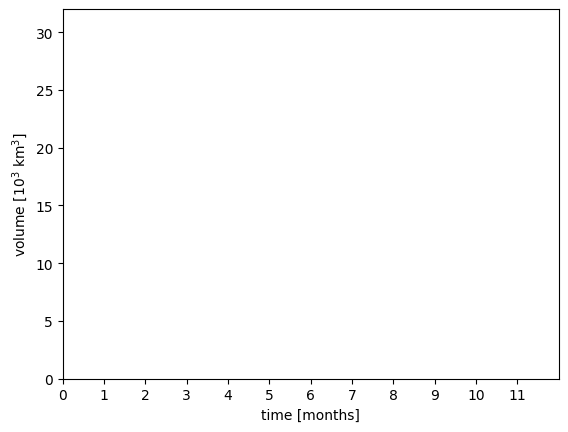

In [ ]:
Qin = 15.7 # Inflow [Sv]
Qout = 15.7 # Outflow [Sv]
M = 16 # reservoir volume [10^3 km^3]

# Create the animation
create_animation(M, Qin, Qout)

## Temporal characteristics

### Steady state
Steady state is obtained when the mass $M$ does not change, $\mathrm{d}M/\mathrm{d}t = 0$. From the conservation law, we see that this is equivalent to the inflows balancing the outflows, or $Q_{\mathrm{in}} = Q_{\mathrm{out}}$. This was our initial setting in the simulation.


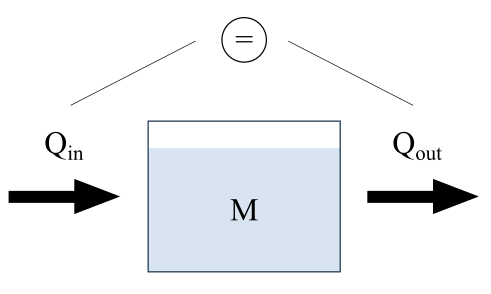

Is the ocean in our three-compartment representation of the water cycle over an entire year in steady state? The ocean receives $12.2\,\mathrm{Sv}$ from the atmosphere and $1.3\,\mathrm{Sv}$ from the land, so the total inflow $Q_{\mathrm{in}} = 13.5\,\mathrm{Sv}$. This is also equal, to within the provided accuracy, to $Q_{\mathrm{out}} = 13.5\,\mathrm{Sv}$ lost to the atmosphere. Hence, the ocean is in steady state on annual time scales according to this model.


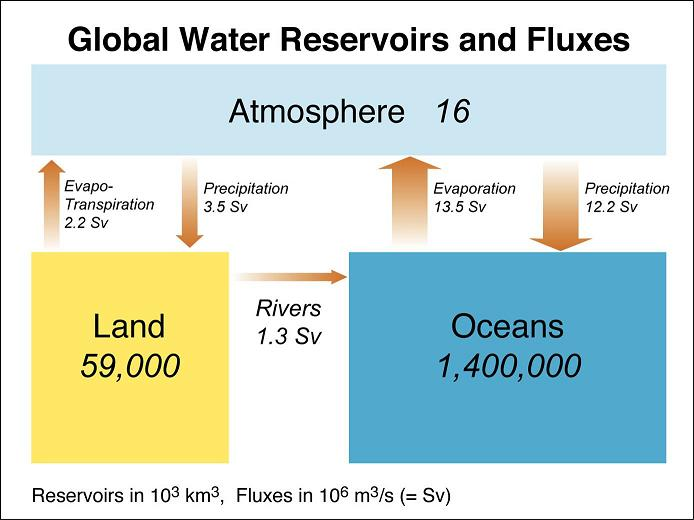

*Three-compartment representation of the global water cycle by Raymond W. Schmitt*.

### Turnover times
How does the size of a reservoir compare to the inflows and/or outflows? The turnover time (sometimes also called residence time) is the time it would take to empty the compartment if the outflow remained constant and the inflow were shut off, or

$$\tau_{\mathrm{t}} = \frac{M}{Q_{\mathrm{out}}}\,.$$


For a given outflow, the turnover time increases with the size of the compartment. For a given compartment size, the greater the outflow, the shorter the turnover time.

Let us turn to our example of the global water cycle. The ocean contains 1.4$\cdot$10$^{18}$ m$^3$ of water and loses, on average, 1.4$\cdot$10$^7$ m$^3$/s through evaporation to the atmosphere. The ratio between the two is approximately 3000 years. Intuitively speaking, it responds much more slowly than the atmosphere, whose turnover time of ~10 days you saw in the animation.



### 😱 Particle residence times

A related concept that applies to discrete particles such as water molecules is that of the (particle) residence time, sometimes also referred to as transit time. It is the average time an individual particle spends in the compartment before leaving it.





The residence time is, in general, different from the turnover time as we defined it. However, the residence time is equal to the turnover time for a system in steady state with constant flows. Also note that many people refer to the turnover time as residence time, so you should also ask for a precise definition.

#### Think about this at home

The ice cover on an Arctic lake of area $A$ furnishes a good example of particle residence and turnover times of a system not in steady state. We will make crude assumptions to showcase the difference between the two. Suppose the ice starts to grow on November 1, its thickness $d$ increasing at a constant rate until April 30, when  $d = 1\,\mathrm{m}$ on April 30. From May 1 to July 1, the ice melts at a constant rate.
*   Determine the outflow $Q_{\mathrm{out}}$ at the beginning of the melt period
*   Compute the instantaneous turnover time at the beginning of the melt period.
*   Determine the average residence time.

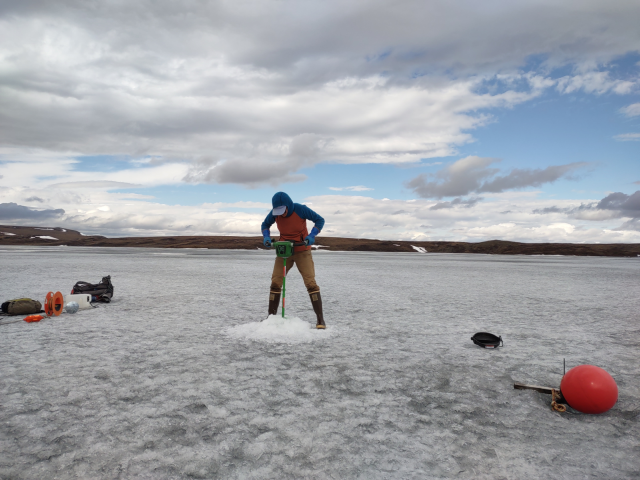

*Photo by Amanda Young*